In [1]:
import os
import sys
import yaml
import torch
import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split

# =====================================================================
# 0. CONFIGURATION & CUSTOM IMPORTS
# =====================================================================
# Adjust the path below to point to where your Classifier.py is saved
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF


# Paths
dataset_path = "Final_Dataset"
model_path = "Models_Extrapolation"
config_path = "configs"  # Ensure your reweight_physics.yml is here
os.makedirs(model_path, exist_ok=True)

device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

# Define the features exactly as they appear in the parquet files
# Context variables and Kinematic features are bundled together
features_to_train = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Control Regions to train the separate component-wise transfer factors
regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

Using device: cpu


/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [19]:
import os
import sys
import yaml
import torch
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

# =====================================================================
# 0. CONFIGURATION & CUSTOM IMPORTS
# =====================================================================
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
# from SimpleMAF import SimpleMAF # Uncomment if needed later

dataset_path = "Final_Dataset"
model_path = "Models_Extrapolation"
config_path = "configs"  
os.makedirs(model_path, exist_ok=True)

device = torch.device("cuda" if False else "cpu")
print(f"Using device: {device}")

features_to_train = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

regions_to_load = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

# --- NEW: TRAINING MODE TOGGLE ---
TRAIN_MODE = "separate"  # Set to "separate" (1 model per CR) or "combined" (1 model for all CRs)
N_ENSEMBLES = 1          
USE_WEIGHTS = True       

def regularize_weights(weights, sigma=3.0):
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

# =====================================================================
# 1. LOAD AND ORGANIZE DATASETS BASED ON MODE
# =====================================================================
training_tasks = {} # Will hold format: {"RunName": (df_mc, df_data)}

print(f"\nPreparing data in '{TRAIN_MODE}' mode...")

if TRAIN_MODE == "separate":
    for region in regions_to_load:
        try:
            df_mc = pl.read_parquet(f"{dataset_path}/MC_{region}.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/DATA_{region}.parquet").to_pandas()
            training_tasks[region] = (df_mc, df_data)
        except Exception as e:
            print(f"Skipping {region} (Files not found or error loading: {e})")

elif TRAIN_MODE == "combined":
    all_mc = []
    all_data = []
    for region in regions_to_load:
        try:
            all_mc.append(pl.read_parquet(f"{dataset_path}/MC_{region}.parquet").to_pandas())
            all_data.append(pl.read_parquet(f"{dataset_path}/DATA_{region}.parquet").to_pandas())
            print(f"Loaded {region} for combination...")
        except Exception as e:
            print(f"Skipping {region} (Files not found or error loading: {e})")
            
    if all_mc and all_data:
        # Concatenate all regions into single massive dataframes
        df_mc_combined = pd.concat(all_mc, ignore_index=True)
        df_data_combined = pd.concat(all_data, ignore_index=True)
        training_tasks["Combined_CRs"] = (df_mc_combined, df_data_combined)
    else:
        print("No data found to combine!")
        sys.exit()
else:
    print("Invalid TRAIN_MODE. Choose 'separate' or 'combined'.")
    sys.exit()

# =====================================================================
# 2. MAIN TRAINING LOOP OVER CONFIGURED TASKS
# =====================================================================

# 'run_name' will be "CR1L", "CR0L", etc., OR "Combined_CRs"
for run_name, (df_mc, df_data) in training_tasks.items():
    print(f"\n{'='*70}")
    print(f" 🚀 PROCESSING: {run_name}")
    print(f"{'='*70}")
    
    # --- A. Split Datasets (The Anti-Leakage Step) ---
    mc_train, mc_test = train_test_split(df_mc, test_size=0.2, random_state=42)
    data_train, data_test = train_test_split(df_data, test_size=0.2, random_state=42)

    print(f"MC Split   -> Train: {len(mc_train)} | Test: {len(mc_test)}")
    print(f"Data Split -> Train: {len(data_train)} | Test: {len(data_test)}")

    # --- B. Prepare Arrays for PyTorch ---
    x_mc_train = mc_train[features_to_train].values
    x_data_train = data_train[features_to_train].values

    y_mc_train = np.zeros((x_mc_train.shape[0], 1))
    y_data_train = np.ones((x_data_train.shape[0], 1))

    input_x = np.vstack([x_data_train, x_mc_train])
    input_y = np.vstack([y_data_train, y_mc_train])

    # --- C. Handle Optional Weights ---
    if USE_WEIGHTS:
        print("Using sample weights for training.")
        w_data = np.ones((x_data_train.shape[0], 1))
        # Ensure 'final_weight' exists or fall back to 'raw_weights'
        weight_col = 'final_weight'
        w_mc = mc_train[weight_col].values.reshape(-1, 1)
        input_w = np.vstack([w_data, w_mc])
    else:
        print("Training WITHOUT sample weights.")
        input_w = None

    # --- D. Ensemble Training ---
    with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
        params_rw = yaml.safe_load(stream)

    for i in range(N_ENSEMBLES):
        print(f"\n--- Training Ensemble {i+1}/{N_ENSEMBLES} for {run_name} ---")
        
        NN_rw = Classifier(
            n_inputs=len(features_to_train), 
            layers=params_rw.get("layers"), 
            learning_rate=params_rw.get("learning_rate"), 
            device=device
        )

        current_seed = 42 + i*7

        # Tag the model with the run_name (e.g., "reweight_Combined_CRs_ens0")
        model_name = f"reweight_{run_name}_ens{i}"
        
        NN_rw.train(
            input_x=input_x, 
            input_y=input_y, 
            weights=input_w, 
            save_model=True, 
            batch_size=params_rw.get("batch_size"), 
            n_epochs=params_rw.get("n_epochs"), 
            model_name=model_name, 
            outdir=model_path,
            early_stop=True,
            seed=current_seed 
        )

    # # =====================================================================
    # # 3. EVALUATION ON HELD-OUT TEST SET
    # # =====================================================================
    # print(f"\n🧪 Evaluating {run_name} Model on Held-Out Test Set...")
    
    # x_test_mc = mc_test[features_to_train].values
    # w_prob = NN_rw.evaluation(x_test_mc)

    # # Calculate Likelihood Ratio and Regularize
    # w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7) # Safety clip
    # w_cr = (w_prob / (1 - w_prob)).flatten()
    # w_cr_regularized = regularize_weights(w_cr, sigma=3.0)

    # print(f"💾 Saving Train/Test splits and evaluated weights to {dataset_path}/{run_name}...")
    
    # # Avoid SettingWithCopy warnings
    # mc_test = mc_test.copy()
    # mc_test['ml_extrapolation_weight'] = w_cr_regularized

    # Save to dynamic subfolder based on the run_name
    output_subdir = f"{dataset_path}/{run_name}"
    os.makedirs(output_subdir, exist_ok=True)
    
    pl.from_pandas(mc_train).write_parquet(f"{output_subdir}/MC_{run_name}_train.parquet")
    pl.from_pandas(data_train).write_parquet(f"{output_subdir}/DATA_{run_name}_train.parquet")
    pl.from_pandas(data_test).write_parquet(f"{output_subdir}/DATA_{run_name}_test.parquet")
    pl.from_pandas(mc_test).write_parquet(f"{output_subdir}/MC_{run_name}_test.parquet")

    print(f"Results for {run_name}:")
    # print(f" -> Generated {len(w_cr_regularized)} ML weights.")
    # print(f" -> Extrapolation Weight Range: Min {w_cr_regularized.min():.4f} | Max {w_cr_regularized.max():.4f} | Mean {w_cr_regularized.mean():.4f}")

print("\n🎉 Reweight training phase complete!")

Using device: cpu

Preparing data in 'separate' mode...

 🚀 PROCESSING: CR1L
MC Split   -> Train: 276081 | Test: 69021
Data Split -> Train: 28151 | Test: 7038
Using sample weights for training.

--- Training Ensemble 1/1 for CR1L ---


 42%|====      | 21/50 [05:41<07:51, 16.27s/it]


Results for CR1L:

 🚀 PROCESSING: CR1L1B
MC Split   -> Train: 50420 | Test: 12605
Data Split -> Train: 11415 | Test: 2854
Using sample weights for training.

--- Training Ensemble 1/1 for CR1L1B ---


 16%|=>        | 8/50 [02:08<11:14, 16.05s/it]


Results for CR1L1B:

 🚀 PROCESSING: CR2L
MC Split   -> Train: 105147 | Test: 26287
Data Split -> Train: 1428 | Test: 358
Using sample weights for training.

--- Training Ensemble 1/1 for CR2L ---


 12%|=         | 6/50 [01:28<10:51, 14.81s/it]


Results for CR2L:

 🚀 PROCESSING: CR0L
MC Split   -> Train: 219790 | Test: 54948
Data Split -> Train: 414930 | Test: 103733
Using sample weights for training.

--- Training Ensemble 1/1 for CR0L ---


 52%|=====     | 26/50 [06:20<05:50, 14.62s/it]


Results for CR0L:

🎉 Reweight training phase complete!


Using device: cuda
 🔬 INITIATING CLOSURE TESTS (MODE 4)
Mode 4: Combined plot using the COMBINED model.

Plotting Combined_CRs (Using Combined Model)...


/tmp/ipykernel_39519/223076540.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


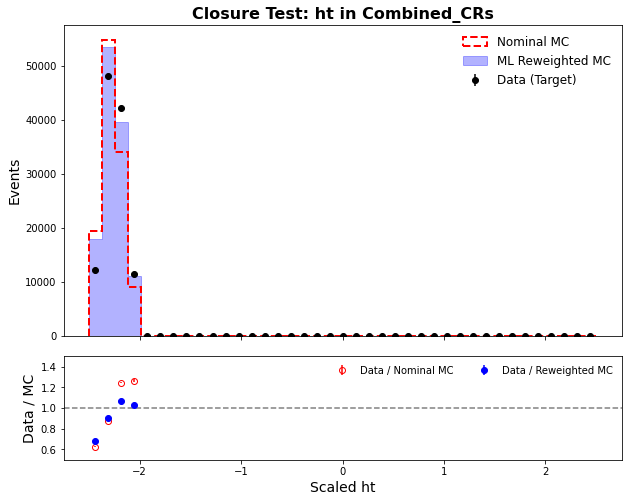

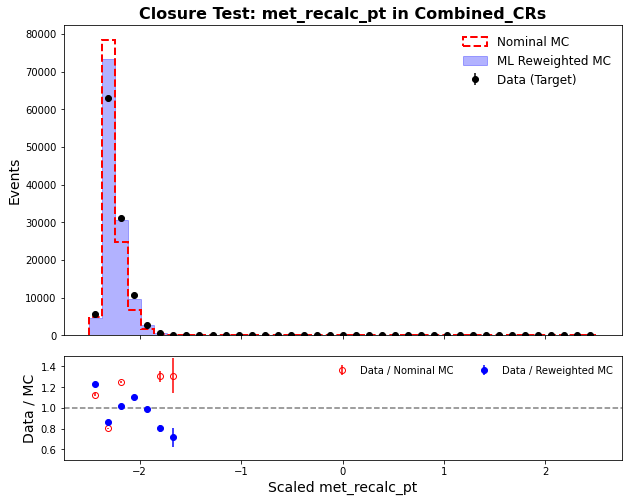

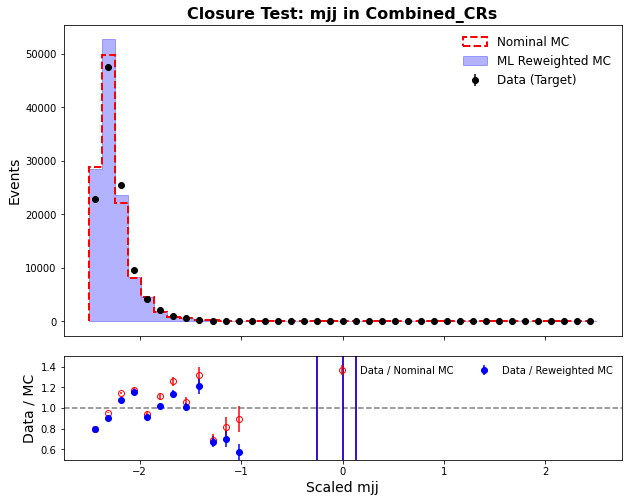

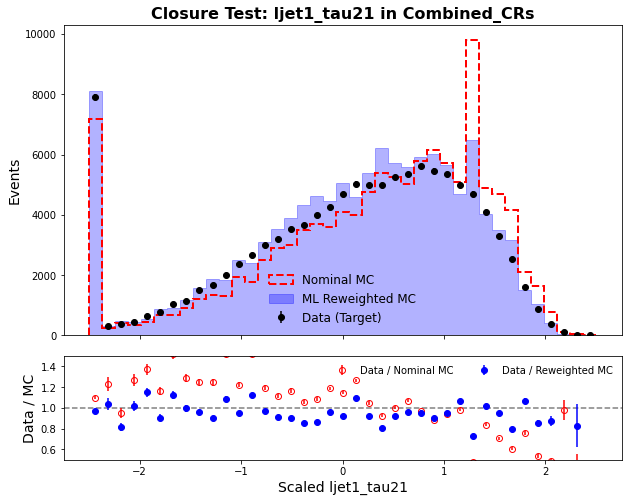

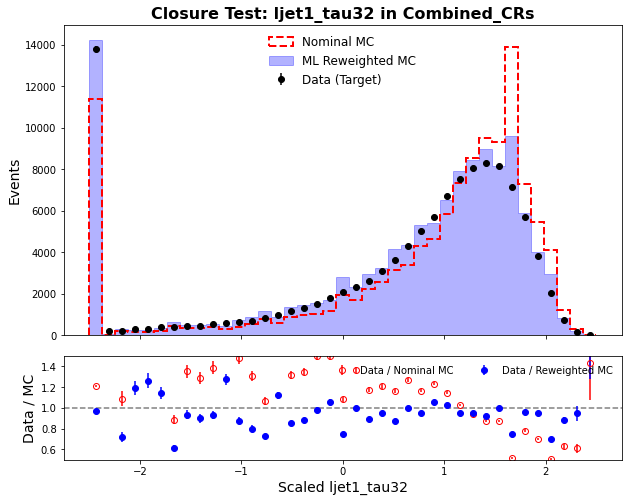

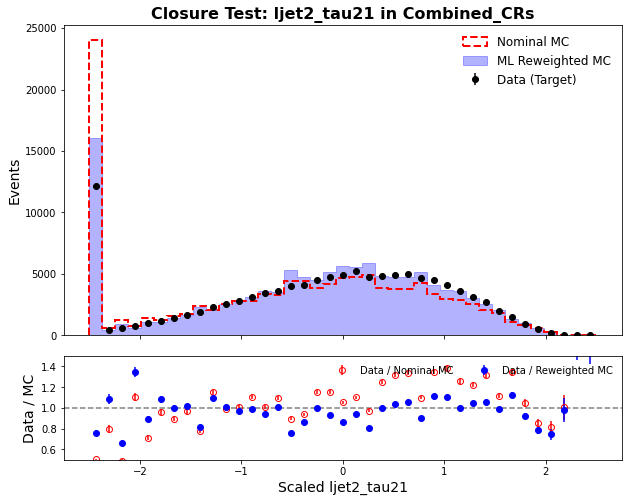

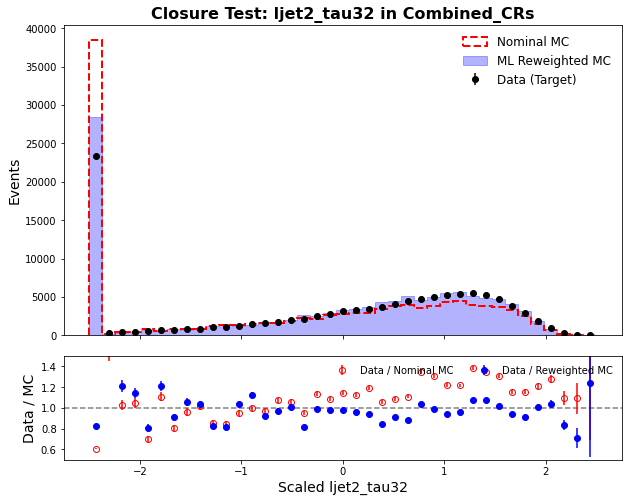

In [22]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Ensure PyTorch can find your Classifier class definition
helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)
from Classifier import Classifier

# =====================================================================
# 1. CONFIGURATION & MODE SELECTION
# =====================================================================
dataset_path = "Final_Dataset"
model_path = "Models_Extrapolation"
plot_dir = "Closure_Plots"
os.makedirs(plot_dir, exist_ok=True)

regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]

features = [
    'ht', 'met_recalc_pt', 'mjj', 
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------------
# SELECT YOUR CLOSURE TEST MODE (1, 2, 3, or 4)
# ---------------------------------------------------------------------
EVALUATION_MODE = 4

# Mode 1: Per-region plot using respective trained reweight
# Mode 2: Per-region plot using the COMBINED trained reweight
# Mode 3: Combined plot using weights from ALL separate regions
# Mode 4: Combined plot using the COMBINED trained reweight

# =====================================================================
# 2. HELPER FUNCTIONS
# =====================================================================
def regularize_weights(weights, sigma=3.0):
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

def evaluate_on_the_fly(model, df_mc_pd, feature_list):
    """Passes data through the model and returns the regularized ML weights."""
    x_test_mc = df_mc_pd[feature_list].values
    w_prob = model.evaluation(x_test_mc)
    w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7) # Prevent divide-by-zero
    w_cr = (w_prob / (1 - w_prob)).flatten()
    return regularize_weights(w_cr, sigma=3.0)

def plot_closure(region_name, df_mc, df_data, feature):
    """Creates a proper HEP closure plot: Main distribution on top, Data/MC ratios on the bottom."""
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    base_weight_col = "final_weight" if "final_weight" in df_mc.columns else "raw_weights"
    raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    ml_weights = df_mc.get_column("ml_extrapolation_weight").to_numpy()
    
    reweighted_mc_weights = raw_weights * ml_weights
    
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    bins = np.linspace(-2.5, 2.5, 40)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # --- MAIN PANEL ---
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
                 color='red', linewidth=2, linestyle='--', label='Nominal MC')
    
    counts_mc_ml, _ = np.histogram(mc_arr, bins=bins, weights=reweighted_mc_weights)
    ax_main.hist(mc_arr, bins=bins, weights=reweighted_mc_weights, histtype='stepfilled', 
                 color='blue', alpha=0.3, edgecolor='blue', label='ML Reweighted MC')
    
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Data (Target)')
    
    ax_main.set_ylabel("Events", fontsize=14)
    ax_main.set_title(f"Closure Test: {feature} in {region_name}", fontsize=16, fontweight='bold')
    ax_main.legend(fontsize=12, frameon=False)
    ax_main.tick_params(labelbottom=False)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_raw = counts_data / counts_mc_raw
        ratio_raw_err = data_errors / counts_mc_raw
        ratio_ml = counts_data / counts_mc_ml
        ratio_ml_err = data_errors / counts_mc_ml
        
        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_ml = np.where(counts_mc_ml > 0, ratio_ml, np.nan)
        ratio_raw_err = np.where(counts_mc_raw > 0, ratio_raw_err, np.nan)
        ratio_ml_err = np.where(counts_mc_ml > 0, ratio_ml_err, np.nan)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='ro', markerfacecolor='none', label='Data / Nominal MC')
    ax_ratio.errorbar(bin_centers, ratio_ml, yerr=ratio_ml_err, fmt='bo', label='Data / Reweighted MC')
    
    ax_ratio.set_xlabel(f"Scaled {feature}", fontsize=14)
    ax_ratio.set_ylabel("Data / MC", fontsize=14)
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
    
    plt.tight_layout()
    plt.show() # Can swap to plt.savefig() if preferred

# =====================================================================
# 3. EXECUTION LOGIC BASED ON MODE
# =====================================================================
print("="*60)
print(f" 🔬 INITIATING CLOSURE TESTS (MODE {EVALUATION_MODE})")
print("="*60)

if EVALUATION_MODE == 1:
    print("Mode 1: Per-region closure using separate models.")
    for region in regions:
        try:
            # Load Data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Load specific model
            model_file = os.path.join(model_path, f"reweight_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            # Evaluate & Append
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(model, df_mc_pd, features)
            df_mc = pl.from_pandas(df_mc_pd)
            
            print(f"\nPlotting {region}...")
            for feature in features:
                plot_closure(region, df_mc, df_data, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 2:
    print("Mode 2: Per-region closure using the COMBINED model.")
    try:
        model_file = os.path.join(model_path, "reweight_Combined_CRs_ens0.pt")
        combined_model = torch.load(model_file, map_location=device, weights_only=False)
        combined_model.to(device)
        print(f"Successfully loaded Combined Model.")
    except Exception as e:
        print(f"Failed to load Combined Model. Error: {e}")
        sys.exit()

    for region in regions:
        try:
            # Load raw test data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Evaluate on the fly using Combined Model
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(combined_model, df_mc_pd, features)
            df_mc = pl.from_pandas(df_mc_pd)
            
            print(f"\nPlotting {region} (Evaluated via Combined Model)...")
            for feature in features:
                plot_closure(f"{region}_via_CombinedModel", df_mc, df_data, feature)
        except Exception as e:
            print(f"Skipping {region}: {e}")

elif EVALUATION_MODE == 3:
    print("Mode 3: Combined plot using separate region weights.")
    mc_dfs = []
    data_dfs = []
    
    for region in regions:
        try:
            # Load Data
            df_mc_pd = pl.read_parquet(f"{dataset_path}/{region}/MC_{region}_test.parquet").to_pandas()
            df_data = pl.read_parquet(f"{dataset_path}/{region}/DATA_{region}_test.parquet")
            
            # Load specific model & Evaluate
            model_file = os.path.join(model_path, f"reweight_{region}_ens0.pt")
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            
            df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(model, df_mc_pd, features)
            
            mc_dfs.append(pl.from_pandas(df_mc_pd))
            data_dfs.append(df_data)
        except Exception as e:
            print(f"Skipping {region} from combination: {e}")
            
    if mc_dfs and data_dfs:
        df_mc_all = pl.concat(mc_dfs)
        df_data_all = pl.concat(data_dfs)
        print("\nPlotting Combined Dataset (Using Separate Models)...")
        for feature in features:
            plot_closure("All_Regions_SeparateModels", df_mc_all, df_data_all, feature)
    else:
        print("No datasets found to combine.")

elif EVALUATION_MODE == 4:
    print("Mode 4: Combined plot using the COMBINED model.")
    run_name = "Combined_CRs"
    try:
        # Load the combined model
        model_file = os.path.join(model_path, f"reweight_{run_name}_ens0.pt")
        combined_model = torch.load(model_file, map_location=device, weights_only=False)
        combined_model.to(device)
        
        # Load the massive combined test sets
        df_mc_pd = pl.read_parquet(f"{dataset_path}/{run_name}/MC_{run_name}_test.parquet").to_pandas()
        df_data = pl.read_parquet(f"{dataset_path}/{run_name}/DATA_{run_name}_test.parquet")
        
        # Evaluate
        df_mc_pd['ml_extrapolation_weight'] = evaluate_on_the_fly(combined_model, df_mc_pd, features)
        df_mc = pl.from_pandas(df_mc_pd)
        
        print(f"\nPlotting {run_name} (Using Combined Model)...")
        for feature in features:
            plot_closure(run_name, df_mc, df_data, feature)
    except Exception as e:
        print(f"Failed to load datasets/models for Mode 4. Error: {e}")

else:
    print("Invalid EVALUATION_MODE. Please select 1, 2, 3, or 4.")

Using device: cuda

Loading scaled Signal Region datasets (SR_clean)...
Loaded 189777 MC events and 22706 Data events.

 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE 2)
Mode 2: Extrapolating using the single 'Combined_CRs' model.

Finalizing datasets and generating plots...
✅ Extrapolated Dataset Saved: Final_Dataset/SR_Extrapolations/MC_SR_clean_extrapolated_Mode2.parquet
📊 Global ML Weight Stats -> Min: 0.6446 | Max: 4.8811 | Mean: 2.5952

Generating SR inspection plots for Mode 2...


/tmp/ipykernel_39519/873169626.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


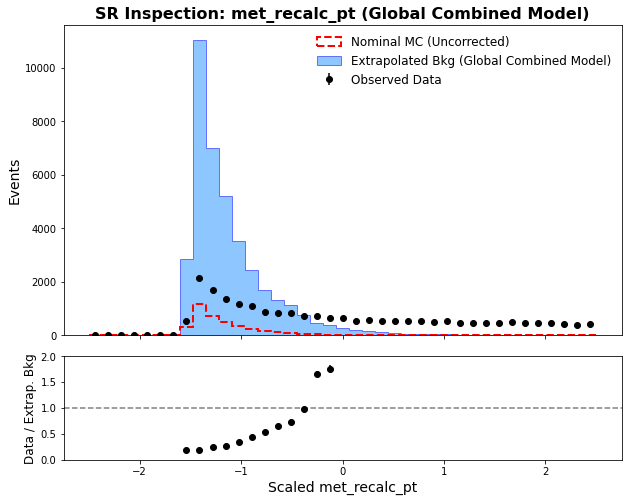

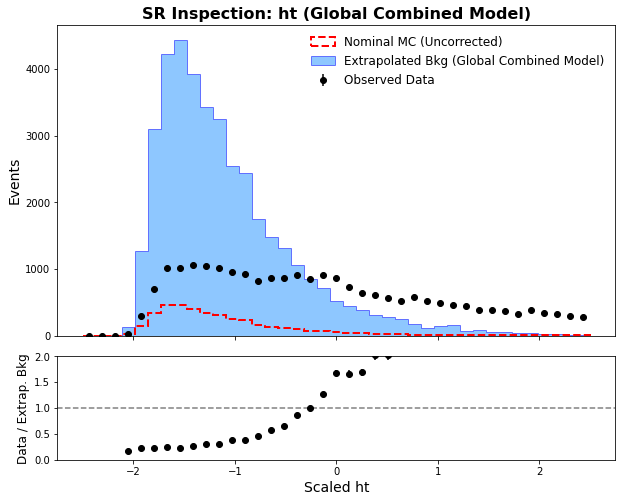

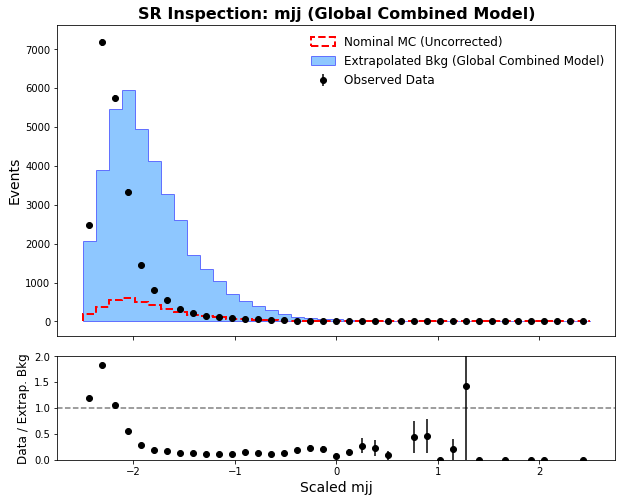

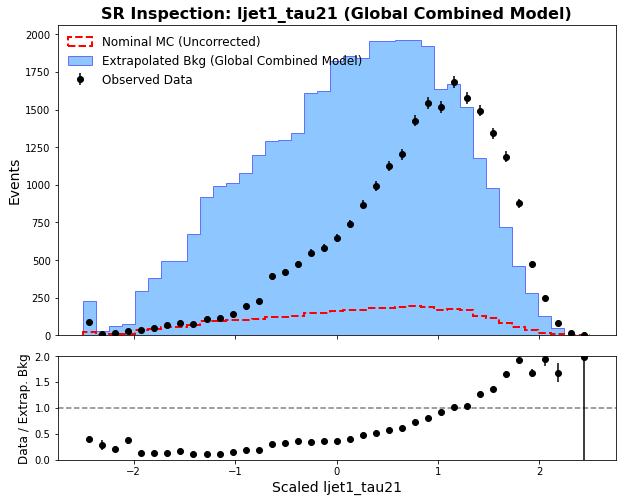

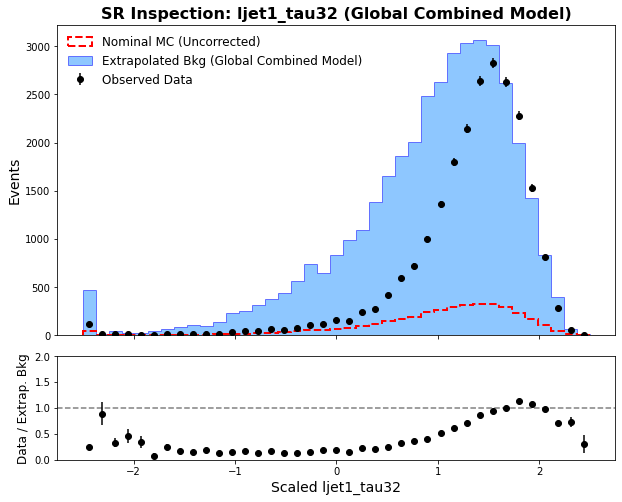

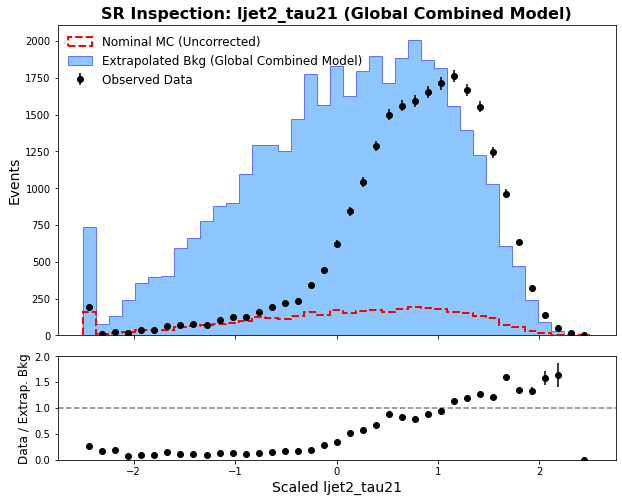

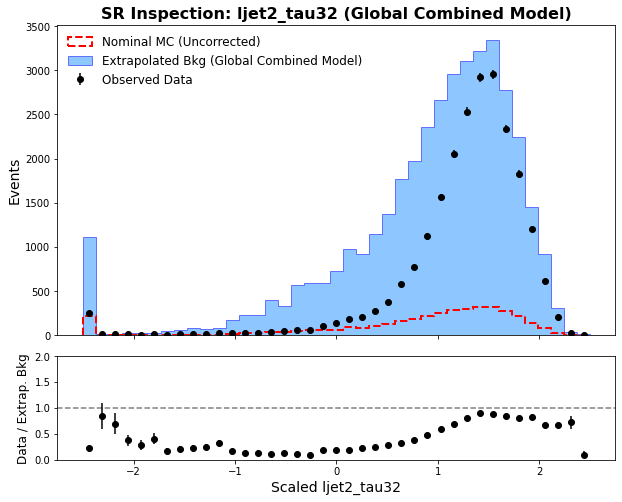


🎉 Extrapolation and Plotting phase complete! Check the 'SR_Extrapolation_Plots' folder.


In [47]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =====================================================================
# 1. CONFIGURATION & IMPORTS
# =====================================================================
helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)

from Classifier import Classifier  

dataset_path = "Final_Dataset"
model_path = "Models_Extrapolation"
target_region = "SR_clean"         

plot_dir = "SR_Extrapolation_Plots"
os.makedirs(plot_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

features_to_evaluate = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# ---------------------------------------------------------------------
# SELECT YOUR EXTRAPOLATION MODE (1, 2, or 3)
# ---------------------------------------------------------------------
EXTRAPOLATION_MODE = 2

# Mode 1: Combine (multiply) the weights from all individual CR models
# Mode 2: Use the weights from the single 'Combined_CRs' model
# Mode 3: Apply specific CR models to specific background processes

N_ENSEMBLES = 1
DENSITY_PLOT = False
# Process Mapping for Mode 3
PROCESS_MAPPING = {
    'Wjets': 'CR1L',
    'ttbar': 'CR1L1B',
    'Single_top': 'CR1L1B',
    'Zjets': 'CR2L',
    'Multijet': 'CR0L',
    'Diboson': 'CR0L' # Defaulting rare backgrounds to the nominal 0L region
}

# =====================================================================
# 2. HELPER & PLOTTING FUNCTIONS
# =====================================================================
def regularize_weights(weights, sigma=3.0):
    """Caps extreme weight hallucinations at 3-sigma above the mean."""
    if len(weights) == 0: return weights
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

def run_ensemble_inference(model_prefix, n_ensembles, x_data):
    """Loads ensemble models, averages probabilities, and returns ML weights."""
    if x_data.shape[0] == 0: return np.array([])
        
    accumulated_probs = np.zeros((x_data.shape[0], 1))
    successful_models = 0
    
    for i in range(n_ensembles):
        model_file = os.path.join(model_path, f"{model_prefix}_ens{i}.pt")
        try:
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            w_prob = model.evaluation(x_data)
            accumulated_probs += w_prob
            successful_models += 1
        except Exception as e:
            print(f"    [!] Failed to load {model_file}: {e}")
            
    if successful_models == 0:
        raise RuntimeError(f"No models found for prefix: {model_prefix}")
        
    avg_prob = accumulated_probs / successful_models
    avg_prob = np.clip(avg_prob, 1e-7, 1.0 - 1e-7)
    w_ml = (avg_prob / (1 - avg_prob)).flatten()
    
    return regularize_weights(w_ml, sigma=3.0)

def plot_sr_extrapolation(mode_label, df_mc, df_data, feature):
    """Plots Extrapolated Background vs Observed Data in the Signal Region."""
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    base_weight_col = "final_weight"
    raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    
    # Use the finalized extrapolated weight directly from the dataframe
    extrapolated_weights = df_mc.get_column("extrapolated_SR_weight").to_numpy()
    extrapolated_weights = extrapolated_weights*4
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    bins = np.linspace(-2.5, 2.5, 40)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # --- MAIN PANEL ---
    # 1. Nominal MC (Uncorrected)
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
                 color='red', linewidth=2, linestyle='--', label='Nominal MC (Uncorrected)', density=DENSITY_PLOT)
    
    # 2. Extrapolated Background
    counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
    ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
                 color='dodgerblue', alpha=0.5, edgecolor='blue', label=f'Extrapolated Bkg ({mode_label})', density=DENSITY_PLOT)
    
    # 3. Target Data
    counts_data, _ = np.histogram(data_arr, bins=bins, density=DENSITY_PLOT)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Observed Data')
    
    ax_main.set_ylabel("Events", fontsize=14)
    ax_main.set_title(f"SR Inspection: {feature} ({mode_label})", fontsize=16, fontweight='bold')
    ax_main.legend(fontsize=12, frameon=False)
    ax_main.tick_params(labelbottom=False)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_extrap = counts_data / counts_mc_extrap
        ratio_extrap_err = data_errors / counts_mc_extrap
        ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
        ratio_extrap_err = np.where(counts_mc_extrap > 0, ratio_extrap_err, np.nan)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='ko')
    
    ax_ratio.set_xlabel(f"Scaled {feature}", fontsize=14)
    ax_ratio.set_ylabel("Data / Extrap. Bkg", fontsize=12)
    ax_ratio.set_ylim(0.0, 2.0) 
    
    plt.tight_layout()
    # save_path = os.path.join(plot_dir, f"SR_Mode{EXTRAPOLATION_MODE}_{feature}.png")
    # plt.savefig(save_path, dpi=300)
    # plt.close()
    plt.show()

# =====================================================================
# 3. LOAD DATASETS
# =====================================================================
print(f"\nLoading scaled Signal Region datasets ({target_region})...")
mc_sr_path = f"{dataset_path}/MC_{target_region}.parquet"
data_sr_path = f"{dataset_path}/DATA_{target_region}.parquet"

try:
    df_mc_sr = pl.read_parquet(mc_sr_path).to_pandas()
    df_data_sr = pl.read_parquet(data_sr_path) # Keep data as polars for plotting
    x_sr_mc = df_mc_sr[features_to_evaluate].values
    print(f"Loaded {df_mc_sr.shape[0]} MC events and {df_data_sr.height} Data events.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    sys.exit(1)

weight_col = 'final_weight'

# =====================================================================
# 4. EXTRAPOLATION LOGIC
# =====================================================================
print("\n" + "="*70)
print(f" 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE {EXTRAPOLATION_MODE})")
print("="*70)

mode_label = f"Mode {EXTRAPOLATION_MODE}"

if EXTRAPOLATION_MODE == 1:
    print("Mode 1: Combining (multiplying) weights from all separate CR models.")
    regions = ["CR1L", "CR1L1B", "CR2L", "CR0L"]
    df_mc_sr['ml_extrapolation_weight'] = 1.0
    
    for region in regions:
        print(f" -> Applying corrections from {region}...")
        try:
            ml_weights = run_ensemble_inference(f"reweight_{region}", N_ENSEMBLES, x_sr_mc)
            df_mc_sr['ml_extrapolation_weight'] *= ml_weights 
        except RuntimeError as e:
            print(f"    [Skipping] {region}: {e}")
            
    df_mc_sr['ml_extrapolation_weight'] = regularize_weights(df_mc_sr['ml_extrapolation_weight'].values, sigma=3.0)
    mode_label = "Multiplied CRs"

elif EXTRAPOLATION_MODE == 2:
    print("Mode 2: Extrapolating using the single 'Combined_CRs' model.")
    try:
        ml_weights = run_ensemble_inference("reweight_Combined_CRs", N_ENSEMBLES, x_sr_mc)
        df_mc_sr['ml_extrapolation_weight'] = ml_weights
        mode_label = "Global Combined Model"
    except RuntimeError as e:
        print(f"Failed to run Combined model: {e}")
        sys.exit(1)

elif EXTRAPOLATION_MODE == 3:
    print("Mode 3: Process-Specific Component Extrapolation.")
    df_mc_sr['ml_extrapolation_weight'] = 1.0
    unique_processes = df_mc_sr['mc_process'].unique()
    
    for proc in unique_processes:
        target_cr = PROCESS_MAPPING.get(proc, 'CR0L')
        print(f" -> Process: {proc:<12} | Assigned Model: {target_cr}")
        
        mask = df_mc_sr['mc_process'] == proc
        x_proc = df_mc_sr.loc[mask, features_to_evaluate].values
        
        if x_proc.shape[0] > 0:
            try:
                ml_weights = run_ensemble_inference(f"reweight_{target_cr}", N_ENSEMBLES, x_proc)
                df_mc_sr.loc[mask, 'ml_extrapolation_weight'] = ml_weights
            except RuntimeError as e:
                print(f"    [!] Failed to evaluate {proc}: {e}")
                
    mode_label = "Process-Mapped"

else:
    print("Invalid EXTRAPOLATION_MODE. Please select 1, 2, or 3.")
    sys.exit(1)

# =====================================================================
# 5. CALCULATE FINAL WEIGHTS, SAVE, AND PLOT
# =====================================================================
print("\nFinalizing datasets and generating plots...")

# Calculate the final physics weight
df_mc_sr['extrapolated_SR_weight'] = df_mc_sr[weight_col] * df_mc_sr['ml_extrapolation_weight']

# Convert back to Polars for saving and plotting
df_mc_sr_polars = pl.from_pandas(df_mc_sr)

# Setup output directory
output_dir = os.path.join(dataset_path, "SR_Extrapolations")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"MC_{target_region}_extrapolated_Mode{EXTRAPOLATION_MODE}.parquet")

# Save as Parquet
df_mc_sr_polars.write_parquet(output_path)
print(f"✅ Extrapolated Dataset Saved: {output_path}")
print(f"📊 Global ML Weight Stats -> Min: {df_mc_sr['ml_extrapolation_weight'].min():.4f} | Max: {df_mc_sr['ml_extrapolation_weight'].max():.4f} | Mean: {df_mc_sr['ml_extrapolation_weight'].mean():.4f}")

# Generate Plots
print(f"\nGenerating SR inspection plots for Mode {EXTRAPOLATION_MODE}...")
for feature in features_to_evaluate:
    plot_sr_extrapolation(mode_label, df_mc_sr_polars, df_data_sr, feature)

print("\n🎉 Extrapolation and Plotting phase complete! Check the 'SR_Extrapolation_Plots' folder.")

Using device: cuda

Loading scaled Signal Region datasets (SR_clean)...
Loaded 189777 MC events and 22706 Data events.

 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE: COMBINED)

[Combined_CRs] Running SR Extrapolation...
    -> Evaluated reweight_Combined_CRs_ens0.pt
  ✅ Saved Extrapolated Dataset to: Final_Dataset/SR_Extrapolations/MC_SR_clean_extrap_by_Combined_CRs.parquet
  📊 ML Weight Stats -> Min: 0.6446 | Max: 4.8811 | Mean: 2.5952
[Combined_CRs] Generating SR inspection plots...


/tmp/ipykernel_39519/2358826514.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


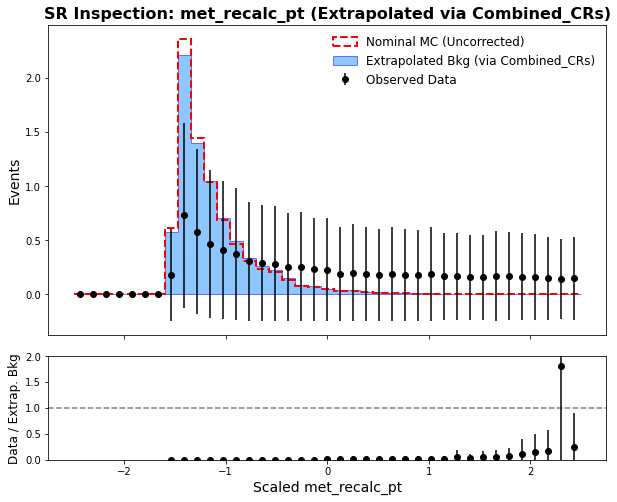

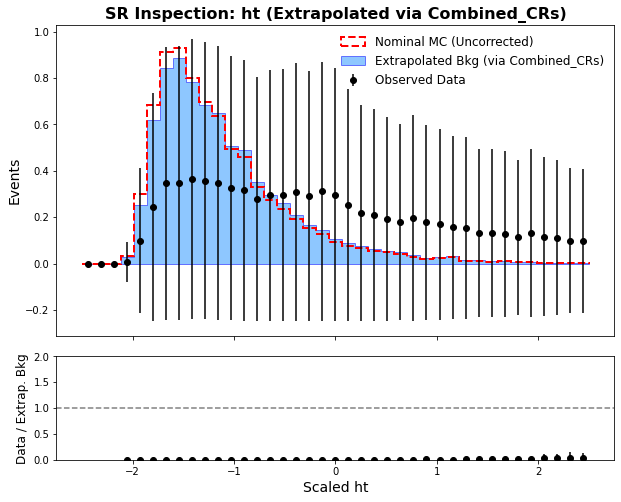

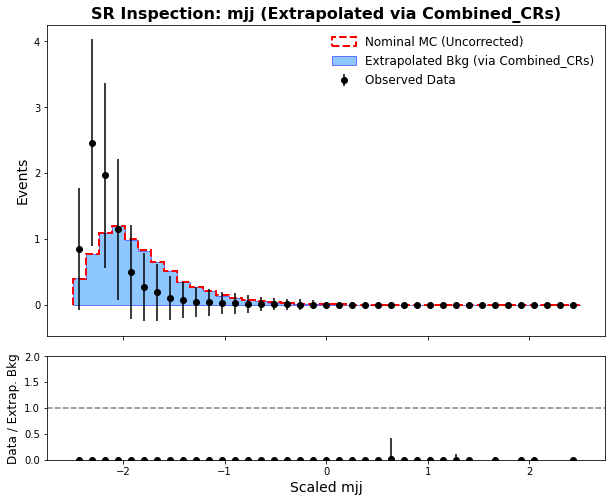

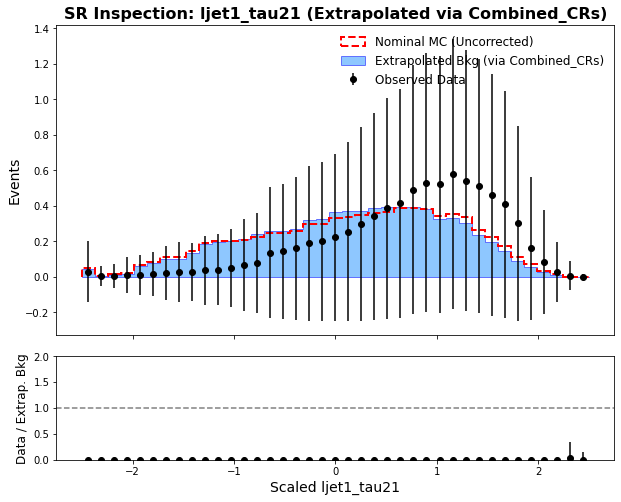

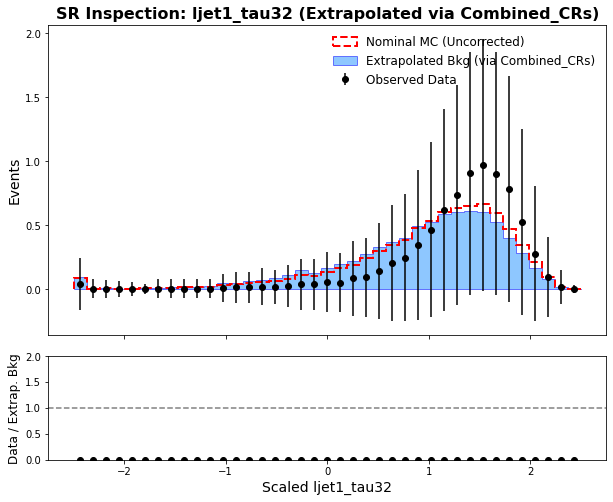

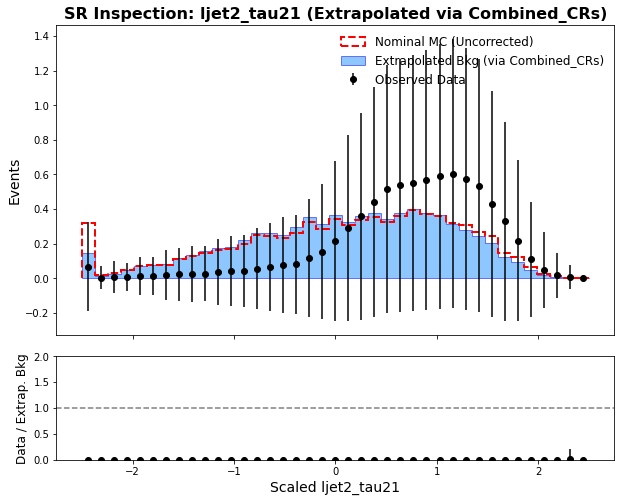

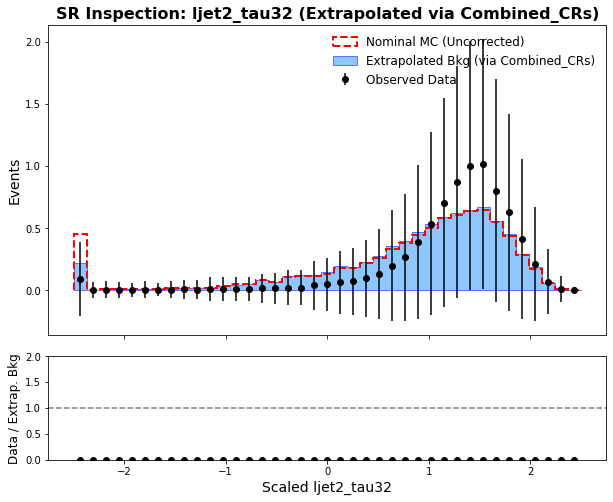


🎉 Extrapolation & Plotting complete! Check the 'SR_Extrapolation_Plots' directory.


In [ ]:
# import os
# import sys
# import torch
# import numpy as np
# import polars as pl
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# # =====================================================================
# # 1. CONFIGURATION & IMPORTS
# # =====================================================================
# helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
# if helpers_path not in sys.path:
#     sys.path.insert(0, helpers_path)

# from Classifier import Classifier  # Required in scope for torch.load()

# dataset_path = "Final_Dataset"
# model_path = "Models_Extrapolation"
# target_region = "SR_clean"         # The dataset we are extrapolating INTO

# plot_dir = "SR_Extrapolation_Plots"
# os.makedirs(plot_dir, exist_ok=True)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# features = [
#     'met_recalc_pt', 'ht', 
#     'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
# ]

# # ---------------------------------------------------------------------
# # SELECT YOUR EXTRAPOLATION MODE
# # ---------------------------------------------------------------------
# EXTRAPOLATION_MODE = "combined"  # Options: "separate" or "combined"
# N_ENSEMBLES = 1                  # Set to the number of ensembles you trained

# # =====================================================================
# # 2. HELPER & PLOTTING FUNCTIONS
# # =====================================================================
# def regularize_weights(weights, sigma=3.0):
#     """Caps extreme weight hallucinations at 3-sigma above the mean."""
#     mean_w = np.mean(weights)
#     std_w = np.std(weights)
#     upper_bound = mean_w + (sigma * std_w)
#     return np.clip(weights, a_min=0, a_max=upper_bound)

# def run_ensemble_inference(model_prefix, n_ensembles, x_data):
#     """Loads ensemble models, averages probabilities, and returns ML weights."""
#     accumulated_probs = np.zeros((x_data.shape[0], 1))
#     successful_models = 0
    
#     for i in range(n_ensembles):
#         model_file = os.path.join(model_path, f"{model_prefix}_ens{i}.pt")
#         try:
#             model = torch.load(model_file, map_location=device, weights_only=False)
#             model.to(device)
#             w_prob = model.evaluation(x_data)
#             accumulated_probs += w_prob
#             successful_models += 1
#             print(f"    -> Evaluated {model_prefix}_ens{i}.pt")
#         except Exception as e:
#             print(f"    [!] Failed to load {model_file}: {e}")
            
#     if successful_models == 0:
#         raise RuntimeError(f"No models found for prefix: {model_prefix}")
        
#     avg_prob = accumulated_probs / successful_models
#     avg_prob = np.clip(avg_prob, 1e-7, 1.0 - 1e-7)
#     w_ml = (avg_prob / (1 - avg_prob)).flatten()
    
#     return regularize_weights(w_ml, sigma=3.0)

# def plot_sr_extrapolation(trained_on_name, df_mc, df_data, ml_weights, feature):
#     """Plots Extrapolated Background vs Observed Data in the Signal Region."""
#     data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
#     mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
#     base_weight_col = "final_weight" if "final_weight" in df_mc.columns else "raw_weights"
#     raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    
#     # Apply the ML correction
#     extrapolated_weights = raw_weights * ml_weights
    
#     fig = plt.figure(figsize=(10, 8))
#     gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
#     ax_main = fig.add_subplot(gs[0])
#     ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
#     bins = np.linspace(-2.5, 2.5, 40)
#     bin_centers = (bins[:-1] + bins[1:]) / 2

#     # --- MAIN PANEL ---
#     # 1. Nominal MC (Pre-ML correction)
#     counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
#     ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
#                  color='red', linewidth=2, linestyle='--', label='Nominal MC (Uncorrected)', density=True)
    
#     # 2. Extrapolated Background
#     counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
#     ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
#                  color='dodgerblue', alpha=0.5, edgecolor='blue', label=f'Extrapolated Bkg (via {trained_on_name})', density=True)
    
#     # 3. Target Data
#     counts_data, _ = np.histogram(data_arr, bins=bins, density=True)
#     data_errors = np.sqrt(counts_data)
#     ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Observed Data')
    
#     ax_main.set_ylabel("Events", fontsize=14)
#     ax_main.set_title(f"SR Inspection: {feature} (Extrapolated via {trained_on_name})", fontsize=16, fontweight='bold')
#     ax_main.legend(fontsize=12, frameon=False)
#     ax_main.tick_params(labelbottom=False)
    
#     # --- RATIO PANEL ---
#     with np.errstate(divide='ignore', invalid='ignore'):
#         ratio_extrap = counts_data / counts_mc_extrap
#         ratio_extrap_err = data_errors / counts_mc_extrap
        
#         ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
#         ratio_extrap_err = np.where(counts_mc_extrap > 0, ratio_extrap_err, np.nan)

#     ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
#     ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='ko')
    
#     ax_ratio.set_xlabel(f"Scaled {feature}", fontsize=14)
#     ax_ratio.set_ylabel("Data / Extrap. Bkg", fontsize=12)
#     ax_ratio.set_ylim(0.0, 2.0) # Wider zoom to catch anomalies!
    
#     plt.tight_layout()
#     # save_path = os.path.join(plot_dir, f"SR_{trained_on_name}_{feature}.png")
#     # plt.savefig(save_path, dpi=300)
#     # plt.close()
#     plt.show()

# # =====================================================================
# # 3. LOAD DATASETS
# # =====================================================================
# print(f"\nLoading scaled Signal Region datasets ({target_region})...")
# mc_sr_path = f"{dataset_path}/MC_{target_region}.parquet"
# data_sr_path = f"{dataset_path}/DATA_{target_region}.parquet"

# try:
#     df_mc_sr_raw = pl.read_parquet(mc_sr_path).to_pandas()
#     df_data_sr = pl.read_parquet(data_sr_path) # Keep as polars for plotting
#     x_sr_mc = df_mc_sr_raw[features].values
#     print(f"Loaded {x_sr_mc.shape[0]} MC events and {df_data_sr.height} Data events.")
# except FileNotFoundError as e:
#     print(f"Error: {e}")
#     sys.exit(1)

# weight_col = 'final_weight' if 'final_weight' in df_mc_sr_raw.columns else 'raw_weights'

# # =====================================================================
# # 4. EXTRAPOLATION & PLOTTING LOGIC
# # =====================================================================
# print("\n" + "="*70)
# print(f" 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE: {EXTRAPOLATION_MODE.upper()})")
# print("="*70)

# models_to_run = []
# if EXTRAPOLATION_MODE == "separate":
#     models_to_run = ["CR1L", "CR1L1B", "CR2L", "CR0L"]
# elif EXTRAPOLATION_MODE == "combined":
#     models_to_run = ["Combined_CRs"]
# else:
#     print("Invalid mode. Choose 'separate' or 'combined'.")
#     sys.exit(1)

# for trained_region in models_to_run:
#     print(f"\n[{trained_region}] Running SR Extrapolation...")
#     model_prefix = f"reweight_{trained_region}"
#     df_mc_sr = df_mc_sr_raw.copy()
    
#     try:
#         # 1. Inference
#         ml_weights = run_ensemble_inference(model_prefix, N_ENSEMBLES, x_sr_mc)
        
#         # 2. Attach Weights and Save Dataset
#         df_mc_sr['ml_extrapolation_weight'] = ml_weights
#         df_mc_sr['extrapolated_SR_weight'] = df_mc_sr[weight_col] * df_mc_sr['ml_extrapolation_weight']
        
#         output_dir = os.path.join(dataset_path, "SR_Extrapolations")
#         os.makedirs(output_dir, exist_ok=True)
#         output_path = os.path.join(output_dir, f"MC_{target_region}_extrap_by_{trained_region}.parquet")
        
#         df_mc_polars = pl.from_pandas(df_mc_sr)
#         df_mc_polars.write_parquet(output_path)
#         print(f"  ✅ Saved Extrapolated Dataset to: {output_path}")
#         print(f"  📊 ML Weight Stats -> Min: {ml_weights.min():.4f} | Max: {ml_weights.max():.4f} | Mean: {ml_weights.mean():.4f}")
        
#         # 3. Plotting
#         print(f"[{trained_region}] Generating SR inspection plots...")
#         for feature in features:
#             plot_sr_extrapolation(trained_region, df_mc_polars, df_data_sr, ml_weights, feature)
            
#     except RuntimeError as e:
#         print(f"  [Skipping] {e}")

# print("\n🎉 Extrapolation & Plotting complete! Check the 'SR_Extrapolation_Plots' directory.")

In [ ]:
import os
import sys
import torch
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =====================================================================
# 1. CONFIGURATION & IMPORTS
# =====================================================================
helpers_path = os.path.abspath('/home/aegis/Titan1/NRAD/data/model_scripts')
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)

from Classifier import Classifier  # Required in scope for torch.load()

dataset_path = "Final_Dataset"
model_path = "Models_Extrapolation"
target_region = "SR_clean"         # The dataset we are extrapolating INTO

plot_dir = "SR_Extrapolation_Plots"
os.makedirs(plot_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

features = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# ---------------------------------------------------------------------
# SELECT YOUR EXTRAPOLATION MODE
# ---------------------------------------------------------------------
EXTRAPOLATION_MODE = "separate"  # Options: "separate" or "combined"
N_ENSEMBLES = 1                  # Set to the number of ensembles you trained

# =====================================================================
# 2. HELPER & PLOTTING FUNCTIONS
# =====================================================================
def regularize_weights(weights, sigma=3.0):
    """Caps extreme weight hallucinations at 3-sigma above the mean."""
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    upper_bound = mean_w + (sigma * std_w)
    return np.clip(weights, a_min=0, a_max=upper_bound)

def run_ensemble_inference(model_prefix, n_ensembles, x_data):
    """Loads ensemble models, averages probabilities, and returns ML weights."""
    accumulated_probs = np.zeros((x_data.shape[0], 1))
    successful_models = 0
    
    for i in range(n_ensembles):
        model_file = os.path.join(model_path, f"{model_prefix}_ens{i}.pt")
        try:
            model = torch.load(model_file, map_location=device, weights_only=False)
            model.to(device)
            w_prob = model.evaluation(x_data)
            accumulated_probs += w_prob
            successful_models += 1
            print(f"    -> Evaluated {model_prefix}_ens{i}.pt")
        except Exception as e:
            print(f"    [!] Failed to load {model_file}: {e}")
            
    if successful_models == 0:
        raise RuntimeError(f"No models found for prefix: {model_prefix}")
        
    avg_prob = accumulated_probs / successful_models
    avg_prob = np.clip(avg_prob, 1e-7, 1.0 - 1e-7)
    w_ml = (avg_prob / (1 - avg_prob)).flatten()
    
    return regularize_weights(w_ml, sigma=3.0)

def plot_sr_extrapolation(trained_on_name, df_mc, df_data, ml_weights, feature):
    """Plots Extrapolated Background vs Observed Data in the Signal Region."""
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    base_weight_col = "final_weight" if "final_weight" in df_mc.columns else "raw_weights"
    raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    
    # Apply the ML correction
    extrapolated_weights = raw_weights * ml_weights
    
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    bins = np.linspace(-2.5, 2.5, 40)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # --- MAIN PANEL ---
    # 1. Nominal MC (Pre-ML correction)
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
                 color='red', linewidth=2, linestyle='--', label='Nominal MC (Uncorrected)')
    
    # 2. Extrapolated Background
    counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
    ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
                 color='dodgerblue', alpha=0.5, edgecolor='blue', label=f'Extrapolated Bkg (via {trained_on_name})')
    
    # 3. Target Data
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Observed Data')
    
    ax_main.set_ylabel("Events", fontsize=14)
    ax_main.set_title(f"SR Inspection: {feature} (Extrapolated via {trained_on_name})", fontsize=16, fontweight='bold')
    ax_main.legend(fontsize=12, frameon=False)
    ax_main.tick_params(labelbottom=False)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_extrap = counts_data / counts_mc_extrap
        ratio_extrap_err = data_errors / counts_mc_extrap
        
        ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
        ratio_extrap_err = np.where(counts_mc_extrap > 0, ratio_extrap_err, np.nan)

    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='ko')
    
    ax_ratio.set_xlabel(f"Scaled {feature}", fontsize=14)
    ax_ratio.set_ylabel("Data / Extrap. Bkg", fontsize=12)
    ax_ratio.set_ylim(0.0, 2.0) # Wider zoom to catch anomalies!
    
    plt.tight_layout()
    save_path = os.path.join(plot_dir, f"SR_{trained_on_name}_{feature}.png")
    plt.savefig(save_path, dpi=300)
    plt.close()

# =====================================================================
# 3. LOAD DATASETS
# =====================================================================
print(f"\nLoading scaled Signal Region datasets ({target_region})...")
mc_sr_path = f"{dataset_path}/MC_{target_region}.parquet"
data_sr_path = f"{dataset_path}/DATA_{target_region}.parquet"

try:
    df_mc_sr_raw = pl.read_parquet(mc_sr_path).to_pandas()
    df_data_sr = pl.read_parquet(data_sr_path) # Keep as polars for plotting
    x_sr_mc = df_mc_sr_raw[features].values
    print(f"Loaded {x_sr_mc.shape[0]} MC events and {df_data_sr.height} Data events.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    sys.exit(1)

weight_col = 'final_weight' if 'final_weight' in df_mc_sr_raw.columns else 'raw_weights'

# =====================================================================
# 4. EXTRAPOLATION & PLOTTING LOGIC
# =====================================================================
print("\n" + "="*70)
print(f" 🚀 INITIATING SR EXTRAPOLATION & PLOTTING (MODE: {EXTRAPOLATION_MODE.upper()})")
print("="*70)

models_to_run = []
if EXTRAPOLATION_MODE == "separate":
    models_to_run = ["CR1L", "CR1L1B", "CR2L", "CR0L"]
elif EXTRAPOLATION_MODE == "combined":
    models_to_run = ["Combined_CRs"]
else:
    print("Invalid mode. Choose 'separate' or 'combined'.")
    sys.exit(1)

for trained_region in models_to_run:
    print(f"\n[{trained_region}] Running SR Extrapolation...")
    model_prefix = f"reweight_{trained_region}"
    df_mc_sr = df_mc_sr_raw.copy()
    
    try:
        # 1. Inference
        ml_weights = run_ensemble_inference(model_prefix, N_ENSEMBLES, x_sr_mc)
        
        # 2. Attach Weights and Save Dataset
        df_mc_sr['ml_extrapolation_weight'] = ml_weights
        df_mc_sr['extrapolated_SR_weight'] = df_mc_sr[weight_col] * df_mc_sr['ml_extrapolation_weight']
        
        output_dir = os.path.join(dataset_path, "SR_Extrapolations")
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"MC_{target_region}_extrap_by_{trained_region}.parquet")
        
        df_mc_polars = pl.from_pandas(df_mc_sr)
        df_mc_polars.write_parquet(output_path)
        print(f"  ✅ Saved Extrapolated Dataset to: {output_path}")
        print(f"  📊 ML Weight Stats -> Min: {ml_weights.min():.4f} | Max: {ml_weights.max():.4f} | Mean: {ml_weights.mean():.4f}")
        
        # 3. Plotting
        print(f"[{trained_region}] Generating SR inspection plots...")
        for feature in features:
            plot_sr_extrapolation(trained_region, df_mc_polars, df_data_sr, ml_weights, feature)
            
    except RuntimeError as e:
        print(f"  [Skipping] {e}")

print("\n🎉 Extrapolation & Plotting complete! Check the 'SR_Extrapolation_Plots' directory.")

Using device: cuda

Loading scaled Signal Region MC (SR_clean)...
Loaded 189777 events for evaluation.

 🚀 INITIATING SR EXTRAPOLATION (MODE: SEPARATE)

Extrapolating SR using models trained on: CR1L...
    -> Evaluated reweight_CR1L_ens0.pt
  ✅ Success! Saved to: Final_Dataset/SR_Extrapolations/MC_SR_clean_extrapolated_by_CR1L.parquet
  📊 ML Weight Stats -> Min: 0.7729 | Max: 1.1560 | Mean: 0.9048

Extrapolating SR using models trained on: CR1L1B...
    -> Evaluated reweight_CR1L1B_ens0.pt
  ✅ Success! Saved to: Final_Dataset/SR_Extrapolations/MC_SR_clean_extrapolated_by_CR1L1B.parquet
  📊 ML Weight Stats -> Min: 0.7049 | Max: 1.2929 | Mean: 1.0153

Extrapolating SR using models trained on: CR2L...
    -> Evaluated reweight_CR2L_ens0.pt
  ✅ Success! Saved to: Final_Dataset/SR_Extrapolations/MC_SR_clean_extrapolated_by_CR2L.parquet
  📊 ML Weight Stats -> Min: 0.7578 | Max: 1.1229 | Mean: 0.9982

Extrapolating SR using models trained on: CR0L...
    -> Evaluated reweight_CR0L_ens0.pt
  

Loading Signal Region Data for SR_clean...
Loaded 189777 MC events and 22706 Data events.

Generating Signal Region plots...


/tmp/ipykernel_39519/2317333525.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


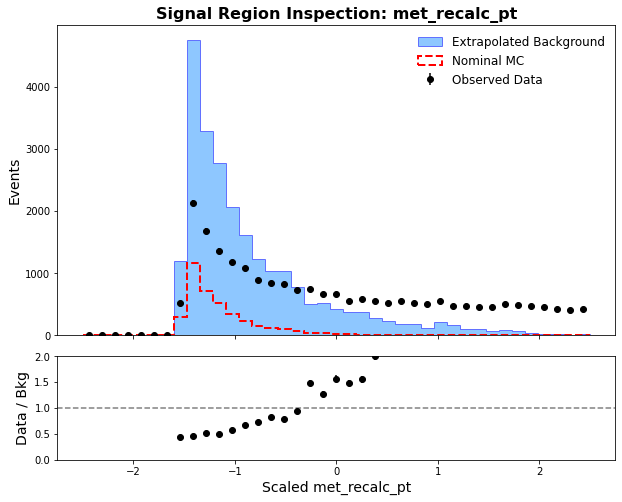

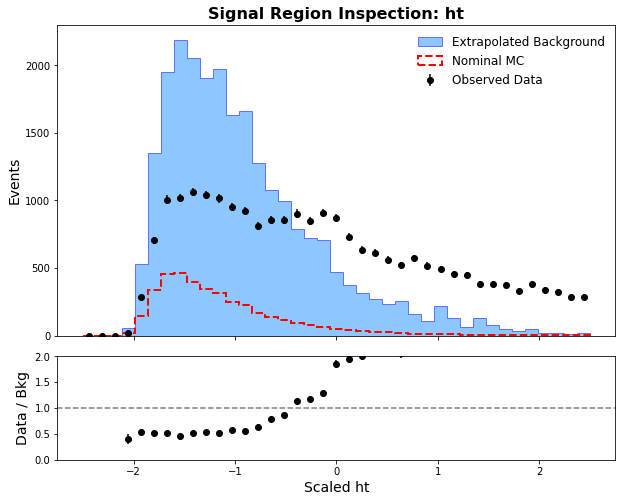

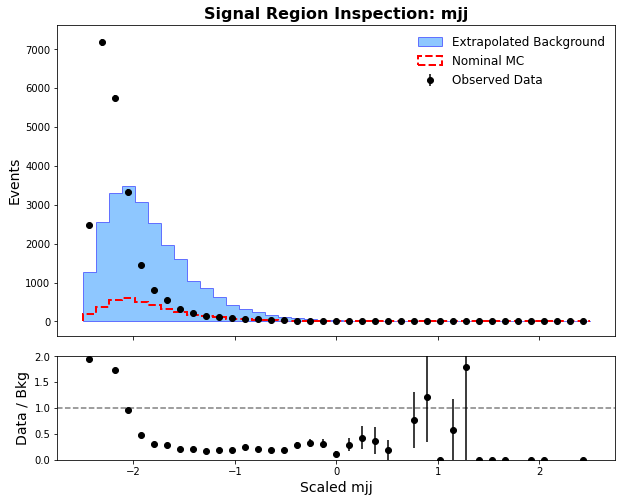

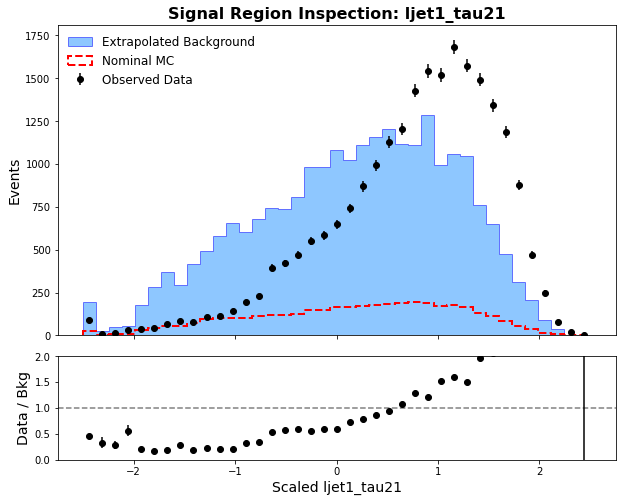

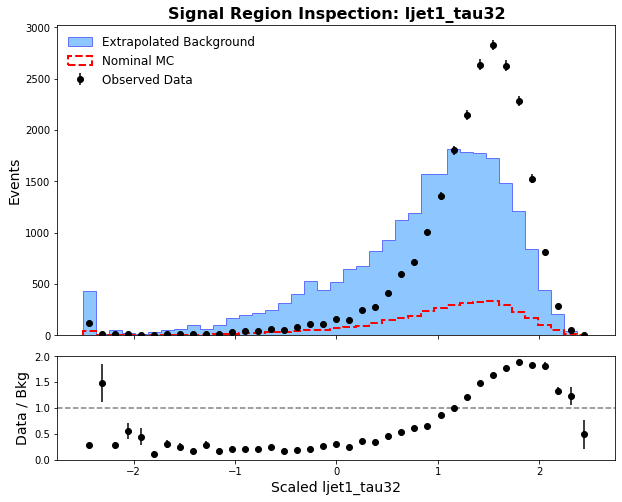

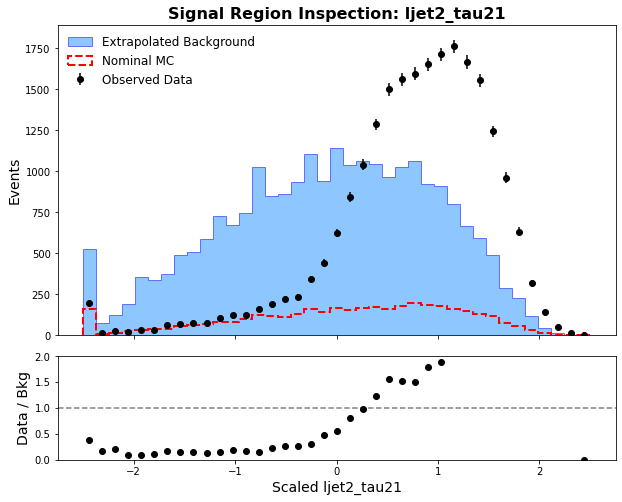

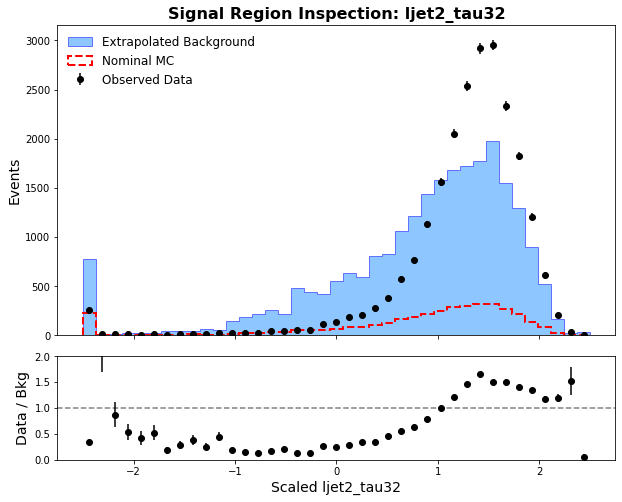


🎉 All SR plots generated successfully! Check the 'SR_Plots' directory.


In [14]:
import os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
dataset_path = "Final_Dataset"
plot_dir = "SR_Plots"
os.makedirs(plot_dir, exist_ok=True)

target_region = "SR_clean"

# The exact features we want to inspect
features = [
    'met_recalc_pt', 'ht', 'mjj', 
    'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# =====================================================================
# 2. LOAD DATA
# =====================================================================
print(f"Loading Signal Region Data for {target_region}...")

mc_path = f"{dataset_path}/MC_{target_region}_extrapolated.parquet"
data_path = f"{dataset_path}/DATA_{target_region}.parquet"

try:
    df_mc = pl.read_parquet(mc_path)
    df_data = pl.read_parquet(data_path)
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    exit()

print(f"Loaded {df_mc.height} MC events and {df_data.height} Data events.")

# =====================================================================
# 3. PLOTTING FUNCTION
# =====================================================================
def plot_sr_kinematics(df_mc, df_data, feature):
    """
    Plots the Data vs Extrapolated Background in the Signal Region with a ratio panel.
    """
    # Extract arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    
    # Extract the ML-derived extrapolated weight
    extrapolated_weights = df_mc.get_column("extrapolated_SR_weight").to_numpy()
    
    # Setup Figure and GridSpec
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Define bins dynamically based on the scaled [-2.5, 2.5] range
    bins = np.linspace(-2.5, 2.5, 40)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # --- MAIN PANEL ---
    # 1. Plot Extrapolated Background
    base_weight_col = "final_weight"
    
    # Extract Weights
    raw_weights = df_mc.get_column(base_weight_col).to_numpy()
    counts_mc, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
    ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', 
                 color='dodgerblue', alpha=0.5, edgecolor='blue', label='Extrapolated Background')
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', 
                 color='red', linewidth=2, linestyle='--', label='Nominal MC')
    # 2. Plot Target Data
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Observed Data')
    
    ax_main.set_ylabel("Events", fontsize=14)
    ax_main.set_title(f"Signal Region Inspection: {feature}", fontsize=16, fontweight='bold')
    ax_main.legend(fontsize=12, frameon=False)
    ax_main.tick_params(labelbottom=False) 
    
    # --- RATIO PANEL ---
    # Safe division ignoring zeroes
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = counts_data / counts_mc
        ratio_err = data_errors / counts_mc
        
        # Clean up NaNs where denominator was 0
        ratio = np.where(counts_mc > 0, ratio, np.nan)
        ratio_err = np.where(counts_mc > 0, ratio_err, np.nan)

    # Plot Ratio
    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
    
    ax_ratio.set_xlabel(f"Scaled {feature}", fontsize=14)
    ax_ratio.set_ylabel("Data / Bkg", fontsize=14)
    
    # Adjust y-limits for the ratio plot to catch anomalies
    ax_ratio.set_ylim(0.0, 2.0) 
    
    # Save and close
    plt.tight_layout()
    # save_path = os.path.join(plot_dir, f"SR_Plot_{feature}.png")
    # plt.savefig(save_path, dpi=300)
    # plt.close()
    # print(f"Saved SR plot: {save_path}")
    plt.show()
# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
print("\nGenerating Signal Region plots...")
for feature in features:
    plot_sr_kinematics(df_mc, df_data, feature)

print("\n🎉 All SR plots generated successfully! Check the 'SR_Plots' directory.")